DATASET
Shape: (60000, 13)

Columns:
['course_code', 'course_name', 'section_name', 'session_date', 'student_code', 'student_name', 'attendance_status', 'minutes_late', 'source', 'week_number', 'day_of_week', 'session_start_time', 'course_load']

Random 20 rows:
      course_code           course_name section_name session_date  \
36979     STAT101          Statistics I    Section 2   2026-05-09   
53228      PHY101             Physics I    Section 2   2026-04-06   
36824     STAT101          Statistics I    Section 2   2026-05-09   
56195     MATH101            Calculus I    Section 2   2026-05-09   
40890     MATH101            Calculus I    Section 2   2026-02-16   
7922       PHY101             Physics I    Section 2   2026-03-30   
54303     MATH101            Calculus I    Section 3   2026-02-09   
2644      MATH101            Calculus I    Section 2   2026-03-23   
48548      PHY101             Physics I    Section 2   2026-02-09   
55327       CS101  Intro to Programming    Sect

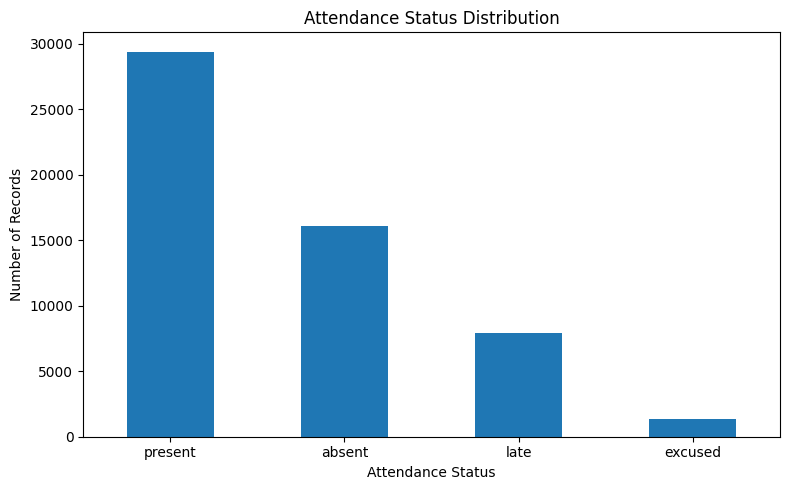


ANOMALY DETECTION

Duplicate attendance records: 54681
Manual attendance records: 2483

Final anomaly report:
student_code  total_records  attended_sessions  counted_sessions  attendance_rate  low_attendance_flag  late_count  late_rate  repeated_late_flag  manual_entry_count  manual_review_flag  anomaly_flag
       S4001            290                184               288         0.638889                    1          93   0.320690                   1                   9                   1             1
       S4003            388                235               384         0.611979                    1          12   0.030928                   1                  16                   1             1
       S4005            407                274               395         0.693671                    1          99   0.243243                   1                  18                   1             1
       S4006            246                124               244         0.508197        

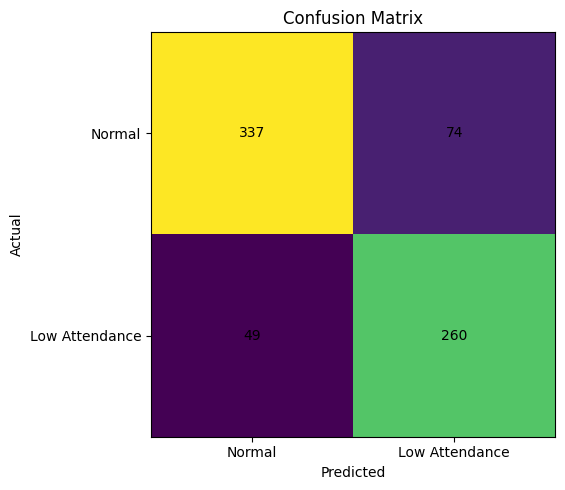


BASELINE VS BALANCED LOGISTIC REGRESSION
   Metric  Rule-Based Baseline  Balanced Logistic Regression
 Accuracy             0.813889                      0.829167
Precision             0.777778                      0.778443
   Recall             0.792880                      0.841424
 F1 Score             0.785256                      0.808709

CALIBRATION
Brier Score: 0.1172

Calibration table:
risk_bin  average_predicted_probability  actual_low_attendance_rate  samples
   0-20%                       0.081902                    0.058824      255
  20-40%                       0.290922                    0.206522       92
  40-60%                       0.502512                    0.404494       89
  60-80%                       0.710782                    0.716981      106
 80-100%                       0.942351                    0.915730      178

FINAL AI RISK RESULTS
student_code  week_number  risk_probability risk_level                                                             

In [7]:
# ============================================================
# SMART ATTENDANCE - AI / ML + ANOMALY DETECTION
# Complete Corrected Version
#
# Required file:
#     attendance_history.csv
#
# Outputs:
#     attendance_ai_predictions.csv
#     attendance_calibration.csv
#     attendance_model_features.csv
#     attendance_baseline_comparison.csv
#     attendance_anomaly_report.csv
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    brier_score_loss
)


# ============================================================
# 1. SETTINGS
# ============================================================

DATA_FILE = "attendance_history_60000.csv"

LOW_ATTENDANCE_THRESHOLD = 0.70
TRAIN_LAST_WEEK = 9


# ============================================================
# 2. LOAD DATA
# ============================================================

df = pd.read_csv(DATA_FILE)

print("=" * 70)
print("DATASET")
print("=" * 70)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nRandom 20 rows:")
print(df.sample(n=min(20, len(df)), random_state=None))


required_columns = [
    "session_date",
    "student_code",
    "attendance_status",
    "week_number",
    "course_load",
    "course_code"
]

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )


# ============================================================
# 3. DATA QUALITY CHECK
# ============================================================

print("\n" + "=" * 70)
print("DATA QUALITY")
print("=" * 70)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nAttendance status:")
print(df["attendance_status"].value_counts())

if "source" in df.columns:
    print("\nSource:")
    print(df["source"].value_counts())


# ============================================================
# 4. CLEAN DATA
# ============================================================

df["session_date"] = pd.to_datetime(
    df["session_date"],
    errors="coerce"
)

df["week_number"] = pd.to_numeric(
    df["week_number"],
    errors="coerce"
)

df["course_load"] = pd.to_numeric(
    df["course_load"],
    errors="coerce"
)

df["attendance_status"] = (
    df["attendance_status"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df = df.dropna(
    subset=[
        "session_date",
        "student_code",
        "week_number",
        "attendance_status"
    ]
)

df["course_load"] = df["course_load"].fillna(
    df["course_load"].median()
)

df = df.drop_duplicates()

df = df.sort_values(
    ["student_code", "session_date"]
).reset_index(drop=True)

print("\nCleaned shape:", df.shape)


# ============================================================
# 5. ATTENDANCE ENCODING
# ============================================================

df["attended"] = (
    df["attendance_status"]
    .isin(["present", "late"])
    .astype(int)
)

df["is_late"] = (
    df["attendance_status"] == "late"
).astype(int)

df["is_absent"] = (
    df["attendance_status"] == "absent"
).astype(int)

df["is_excused"] = (
    df["attendance_status"] == "excused"
).astype(int)

# Only present, late, and absent count in the denominator.
# Excused sessions are excluded.
df["counted_session"] = (
    df["attendance_status"]
    .isin(["present", "late", "absent"])
    .astype(int)
)


# ============================================================
# 6. EDA
# ============================================================

print("\n" + "=" * 70)
print("EDA")
print("=" * 70)

status_counts = df["attendance_status"].value_counts()

plt.figure(figsize=(8, 5))
status_counts.plot(kind="bar")
plt.title("Attendance Status Distribution")
plt.xlabel("Attendance Status")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ============================================================
# 7. ANOMALY DETECTION
# ============================================================

print("\n" + "=" * 70)
print("ANOMALY DETECTION")
print("=" * 70)


# ------------------------------------------------------------
# 7.1 Duplicate attendance records
# ------------------------------------------------------------

duplicate_mask = df.duplicated(
    subset=[
        "student_code",
        "course_code",
        "session_date"
    ],
    keep=False
)

df["duplicate_flag"] = duplicate_mask.astype(int)

duplicate_records = df[
    df["duplicate_flag"] == 1
].copy()

print("\nDuplicate attendance records:", len(duplicate_records))


# ------------------------------------------------------------
# 7.2 Manual attendance entries
# ------------------------------------------------------------

if "source" in df.columns:

    df["manual_entry_flag"] = (
        df["source"]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq("manual")
        .astype(int)
    )

else:

    df["manual_entry_flag"] = 0

print(
    "Manual attendance records:",
    int(df["manual_entry_flag"].sum())
)


# ------------------------------------------------------------
# 7.3 Student-level late attendance
# ------------------------------------------------------------

late_summary = df.groupby(
    "student_code"
).agg(
    total_records=(
        "attendance_status",
        "count"
    ),
    late_count=(
        "is_late",
        "sum"
    )
).reset_index()

late_summary["late_rate"] = np.where(
    late_summary["total_records"] > 0,
    late_summary["late_count"] /
    late_summary["total_records"],
    0
)

# Rule: at least 3 late records
late_summary["repeated_late_flag"] = (
    late_summary["late_count"] >= 3
).astype(int)


# ------------------------------------------------------------
# 7.4 Student-level attendance rate
# ------------------------------------------------------------

attendance_summary = df.groupby(
    "student_code"
).agg(
    total_records=(
        "attendance_status",
        "count"
    ),
    attended_sessions=(
        "attended",
        "sum"
    ),
    counted_sessions=(
        "counted_session",
        "sum"
    )
).reset_index()

attendance_summary["attendance_rate"] = np.where(
    attendance_summary["counted_sessions"] > 0,
    attendance_summary["attended_sessions"] /
    attendance_summary["counted_sessions"],
    np.nan
)

attendance_summary["low_attendance_flag"] = (
    attendance_summary["attendance_rate"] <
    LOW_ATTENDANCE_THRESHOLD
).fillna(False).astype(int)


# ------------------------------------------------------------
# 7.5 Combine anomaly report
# ------------------------------------------------------------

anomaly_report = attendance_summary.merge(
    late_summary[
        [
            "student_code",
            "late_count",
            "late_rate",
            "repeated_late_flag"
        ]
    ],
    on="student_code",
    how="left"
)

manual_summary = df.groupby(
    "student_code"
).agg(
    manual_entry_count=(
        "manual_entry_flag",
        "sum"
    )
).reset_index()

anomaly_report = anomaly_report.merge(
    manual_summary,
    on="student_code",
    how="left"
)

anomaly_report["manual_review_flag"] = (
    anomaly_report["manual_entry_count"] > 0
).astype(int)

# This is a review flag, not a fraud decision.
anomaly_report["anomaly_flag"] = (
    (anomaly_report["low_attendance_flag"] == 1) |
    (anomaly_report["repeated_late_flag"] == 1) |
    (anomaly_report["manual_review_flag"] == 1)
).astype(int)

anomaly_report = anomaly_report.sort_values(
    [
        "anomaly_flag",
        "low_attendance_flag",
        "repeated_late_flag",
        "manual_review_flag"
    ],
    ascending=False
).reset_index(drop=True)

print("\nFinal anomaly report:")
print(anomaly_report.head(20).to_string(index=False))

print("\nAnomaly summary:")
print(anomaly_report["anomaly_flag"].value_counts())

anomaly_report.to_csv(
    "attendance_anomaly_report.csv",
    index=False
)

print("\nSaved: attendance_anomaly_report.csv")


# ============================================================
# 8. WEEKLY STUDENT DATA
# ============================================================

weekly = df.groupby(
    ["student_code", "week_number"]
).agg(
    total_records=("attendance_status", "count"),
    attended=("attended", "sum"),
    late=("is_late", "sum"),
    absent=("is_absent", "sum"),
    excused=("is_excused", "sum"),
    counted_sessions=("counted_session", "sum"),
    avg_course_load=("course_load", "mean")
).reset_index()

weekly["attendance_rate"] = np.where(
    weekly["counted_sessions"] > 0,
    weekly["attended"] /
    weekly["counted_sessions"],
    np.nan
)

weekly["late_rate"] = np.where(
    weekly["counted_sessions"] > 0,
    weekly["late"] /
    weekly["counted_sessions"],
    0
)

weekly["absence_rate"] = np.where(
    weekly["counted_sessions"] > 0,
    weekly["absent"] /
    weekly["counted_sessions"],
    0
)

weekly = weekly.sort_values(
    ["student_code", "week_number"]
).reset_index(drop=True)


# ============================================================
# 9. PREVIOUS-WEEK FEATURES
# ============================================================

weekly["previous_attendance"] = (
    weekly
    .groupby("student_code")["attendance_rate"]
    .shift(1)
)

weekly["previous_late_rate"] = (
    weekly
    .groupby("student_code")["late_rate"]
    .shift(1)
)

weekly["previous_absence_rate"] = (
    weekly
    .groupby("student_code")["absence_rate"]
    .shift(1)
)

weekly["previous_course_load"] = (
    weekly
    .groupby("student_code")["avg_course_load"]
    .shift(1)
)

weekly["recent_3week_attendance"] = (
    weekly
    .groupby("student_code")["attendance_rate"]
    .transform(
        lambda values: values.shift(1).rolling(
            window=3,
            min_periods=1
        ).mean()
    )
)

weekly["attendance_trend"] = (
    weekly["previous_attendance"] -
    weekly["recent_3week_attendance"]
)


# ============================================================
# 10. EXACT NEXT-WEEK TARGET
# ============================================================
#
# We explicitly match week N with week N+1.
# This prevents incorrectly linking non-consecutive weeks.
# ============================================================

next_week_table = weekly[
    [
        "student_code",
        "week_number",
        "attendance_rate"
    ]
].copy()

next_week_table = next_week_table.rename(
    columns={
        "week_number": "next_week_number",
        "attendance_rate": "next_week_attendance"
    }
)

weekly["next_week_number"] = (
    weekly["week_number"] + 1
)

weekly = weekly.merge(
    next_week_table,
    on=[
        "student_code",
        "next_week_number"
    ],
    how="left"
)

weekly["low_attendance_next_week"] = (
    weekly["next_week_attendance"] <
    LOW_ATTENDANCE_THRESHOLD
).astype(int)


# ============================================================
# 11. MODEL DATA
# ============================================================

features = [
    "previous_attendance",
    "recent_3week_attendance",
    "previous_late_rate",
    "previous_absence_rate",
    "previous_course_load",
    "attendance_trend"
]

model_df = weekly.dropna(
    subset=features + ["next_week_attendance"]
).copy()

model_df = model_df.sort_values(
    ["week_number", "student_code"]
).reset_index(drop=True)

print("\n" + "=" * 70)
print("MODEL DATA")
print("=" * 70)

print("Model rows:", len(model_df))

print("\nTarget distribution:")
print(
    model_df["low_attendance_next_week"].value_counts()
)

print("\nTarget percentage:")
print(
    model_df["low_attendance_next_week"]
    .value_counts(normalize=True)
)


# ============================================================
# 12. RULE-BASED BASELINE
# ============================================================

baseline_pred = (
    model_df["previous_attendance"] <
    LOW_ATTENDANCE_THRESHOLD
).astype(int)

baseline_true = model_df[
    "low_attendance_next_week"
]

baseline_accuracy = accuracy_score(
    baseline_true,
    baseline_pred
)

baseline_precision = precision_score(
    baseline_true,
    baseline_pred,
    zero_division=0
)

baseline_recall = recall_score(
    baseline_true,
    baseline_pred,
    zero_division=0
)

baseline_f1 = f1_score(
    baseline_true,
    baseline_pred,
    zero_division=0
)

print("\n" + "=" * 70)
print("RULE-BASED BASELINE")
print("=" * 70)

print("Accuracy :", round(baseline_accuracy, 4))
print("Precision:", round(baseline_precision, 4))
print("Recall   :", round(baseline_recall, 4))
print("F1 Score :", round(baseline_f1, 4))


# ============================================================
# 13. TIME-BASED TRAIN / TEST SPLIT
# ============================================================

train_df = model_df[
    model_df["week_number"] <= TRAIN_LAST_WEEK
].copy()

test_df = model_df[
    model_df["week_number"] > TRAIN_LAST_WEEK
].copy()

print("\n" + "=" * 70)
print("TIME-BASED SPLIT")
print("=" * 70)

if train_df.empty:
    raise ValueError(
        "Training data is empty. Change TRAIN_LAST_WEEK."
    )

if test_df.empty:
    raise ValueError(
        "Testing data is empty. Change TRAIN_LAST_WEEK."
    )

print(
    "Training weeks:",
    train_df["week_number"].min(),
    "to",
    train_df["week_number"].max()
)

print(
    "Testing weeks:",
    test_df["week_number"].min(),
    "to",
    test_df["week_number"].max()
)

print("Training rows:", len(train_df))
print("Testing rows :", len(test_df))

if train_df["low_attendance_next_week"].nunique() < 2:
    raise ValueError(
        "Training data contains only one target class. "
        "Change TRAIN_LAST_WEEK."
    )

if test_df["low_attendance_next_week"].nunique() < 2:
    raise ValueError(
        "Testing data contains only one target class. "
        "Change TRAIN_LAST_WEEK."
    )


# ============================================================
# 14. PREPARE X AND Y
# ============================================================

X_train = train_df[features]
y_train = train_df["low_attendance_next_week"]

X_test = test_df[features]
y_test = test_df["low_attendance_next_week"]


# ============================================================
# 15. BALANCE TRAINING DATA
# ============================================================
# Balance ONLY the training set. The test set stays untouched.
train_model_df = train_df.copy()

class_counts = train_model_df["low_attendance_next_week"].value_counts()

if len(class_counts) != 2:
    raise ValueError("Training data must contain both target classes.")

minority_class = class_counts.idxmin()
majority_class = class_counts.idxmax()

minority_df = train_model_df[
    train_model_df["low_attendance_next_week"] == minority_class
].copy()

majority_df = train_model_df[
    train_model_df["low_attendance_next_week"] == majority_class
].copy()

majority_balanced = resample(
    majority_df,
    replace=False,
    n_samples=len(minority_df),
    random_state=42
)

balanced_train_df = pd.concat(
    [minority_df, majority_balanced],
    ignore_index=True
).sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

X_train = balanced_train_df[features]
y_train = balanced_train_df["low_attendance_next_week"]

print("\n" + "=" * 70)
print("BALANCED TRAINING DATA")
print("=" * 70)
print("Before balancing:")
print(train_df["low_attendance_next_week"].value_counts())
print("\nAfter balancing:")
print(y_train.value_counts())

# ============================================================
# 16. LOGISTIC REGRESSION
# ============================================================

model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "logistic_regression",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

model.fit(
    X_train,
    y_train
)


# ============================================================
# 16. PREDICTIONS
# ============================================================

y_probability = model.predict_proba(
    X_test
)[:, 1]

y_pred = (
    y_probability >= 0.50
).astype(int)


# ============================================================
# 17. MODEL EVALUATION
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print("\n" + "=" * 70)
print("BALANCED LOGISTIC REGRESSION RESULTS")
print("=" * 70)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Normal Attendance",
            "Low Attendance"
        ],
        zero_division=0
    )
)


# ============================================================
# 18. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["Normal", "Low Attendance"]
)

plt.yticks(
    [0, 1],
    ["Normal", "Low Attendance"]
)

for row_index in range(cm.shape[0]):
    for column_index in range(cm.shape[1]):
        plt.text(
            column_index,
            row_index,
            cm[row_index, column_index],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()


# ============================================================
# 19. BASELINE VS MODEL
# ============================================================

test_baseline_pred = (
    test_df["previous_attendance"] <
    LOW_ATTENDANCE_THRESHOLD
).astype(int)

test_baseline_accuracy = accuracy_score(
    y_test,
    test_baseline_pred
)

test_baseline_precision = precision_score(
    y_test,
    test_baseline_pred,
    zero_division=0
)

test_baseline_recall = recall_score(
    y_test,
    test_baseline_pred,
    zero_division=0
)

test_baseline_f1 = f1_score(
    y_test,
    test_baseline_pred,
    zero_division=0
)

comparison_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Rule-Based Baseline": [
        test_baseline_accuracy,
        test_baseline_precision,
        test_baseline_recall,
        test_baseline_f1
    ],
    "Balanced Logistic Regression": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

print("\n" + "=" * 70)
print("BASELINE VS BALANCED LOGISTIC REGRESSION")
print("=" * 70)

print(
    comparison_df.to_string(index=False)
)


# ============================================================
# 20. CALIBRATION / BRIER SCORE
# ============================================================

brier = brier_score_loss(
    y_test,
    y_probability
)

print("\n" + "=" * 70)
print("CALIBRATION")
print("=" * 70)

print("Brier Score:", round(brier, 4))

calibration_df = pd.DataFrame({
    "actual": y_test.to_numpy(),
    "probability": y_probability
})

calibration_df["risk_bin"] = pd.cut(
    calibration_df["probability"],
    bins=[
        -0.001,
        0.20,
        0.40,
        0.60,
        0.80,
        1.00
    ],
    labels=[
        "0-20%",
        "20-40%",
        "40-60%",
        "60-80%",
        "80-100%"
    ]
)

calibration_table = (
    calibration_df
    .groupby(
        "risk_bin",
        observed=False
    )
    .agg(
        average_predicted_probability=(
            "probability",
            "mean"
        ),
        actual_low_attendance_rate=(
            "actual",
            "mean"
        ),
        samples=(
            "actual",
            "count"
        )
    )
    .reset_index()
)

print("\nCalibration table:")
print(
    calibration_table.to_string(index=False)
)


# ============================================================
# 21. FINAL RISK RESULTS
# ============================================================

results = test_df[
    [
        "student_code",
        "week_number",
        "previous_attendance",
        "recent_3week_attendance",
        "previous_late_rate",
        "previous_absence_rate",
        "previous_course_load",
        "attendance_trend"
    ]
].copy()

results["risk_probability"] = y_probability
results["prediction"] = y_pred


# ============================================================
# 22. RISK LEVEL
# ============================================================

def probability_to_risk(probability):

    if probability >= 0.70:
        return "HIGH"

    if probability >= 0.40:
        return "MEDIUM"

    return "LOW"


results["risk_level"] = (
    results["risk_probability"]
    .apply(probability_to_risk)
)


# ============================================================
# 23. EXPLAINABLE AI REASONS
# ============================================================

def generate_explanation(row):

    reasons = []

    if row["previous_attendance"] < 0.70:
        reasons.append(
            "Previous attendance is below 70%"
        )

    if row["recent_3week_attendance"] < 0.70:
        reasons.append(
            "Recent 3-week attendance is below 70%"
        )

    if row["previous_late_rate"] >= 0.30:
        reasons.append(
            "High late-attendance rate"
        )

    if row["previous_absence_rate"] >= 0.30:
        reasons.append(
            "High absence rate"
        )

    if row["attendance_trend"] < 0:
        reasons.append(
            "Attendance trend is decreasing"
        )

    if len(reasons) == 0:
        reasons.append(
            "No major rule-based risk factor detected"
        )

    return "; ".join(reasons)


results["explanation"] = (
    results.apply(
        generate_explanation,
        axis=1
    )
)

results = results.sort_values(
    "risk_probability",
    ascending=False
).reset_index(drop=True)


# ============================================================
# 24. DISPLAY FINAL RESULTS
# ============================================================

display_columns = [
    "student_code",
    "week_number",
    "risk_probability",
    "risk_level",
    "explanation"
]

print("\n" + "=" * 70)
print("FINAL AI RISK RESULTS")
print("=" * 70)

print(
    results[display_columns]
    .head(20)
    .to_string(index=False)
)


# ============================================================
# 25. RISK SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("RISK SUMMARY")
print("=" * 70)

print(
    results["risk_level"].value_counts()
)


# ============================================================
# 26. HIGH-RISK STUDENTS
# ============================================================

high_risk = results[
    results["risk_level"] == "HIGH"
]

print("\nHigh-risk students:")

if high_risk.empty:
    print("No high-risk students detected.")

else:
    print(
        high_risk[display_columns]
        .head(20)
        .to_string(index=False)
    )


# ============================================================
# 27. MODEL FEATURE EFFECTS
# ============================================================

logistic_model = model.named_steps[
    "logistic_regression"
]

coefficients = pd.DataFrame({
    "feature": features,
    "coefficient": logistic_model.coef_[0]
})

coefficients["absolute_effect"] = (
    coefficients["coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "absolute_effect",
    ascending=False
)

print("\n" + "=" * 70)
print("MODEL FEATURE EFFECTS")
print("=" * 70)

print(
    coefficients.to_string(index=False)
)


# ============================================================
# 28. SAVE OUTPUT FILES
# ============================================================

results.to_csv(
    "attendance_ai_predictions.csv",
    index=False
)

calibration_table.to_csv(
    "attendance_calibration.csv",
    index=False
)

coefficients.to_csv(
    "attendance_model_features.csv",
    index=False
)

comparison_df.to_csv(
    "attendance_baseline_comparison.csv",
    index=False
)

print("\n" + "=" * 70)
print("FILES SAVED")
print("=" * 70)

print("attendance_ai_predictions.csv")
print("attendance_calibration.csv")
print("attendance_model_features.csv")
print("attendance_baseline_comparison.csv")
print("attendance_anomaly_report.csv")


# ============================================================
# 29. DATA LIMITATIONS
# ============================================================

print("\n" + "=" * 70)
print("DATA LIMITATIONS")
print("=" * 70)

print(
    "Failed QR scans: no explicit failed-scan field is available."
)

print(
    "Correction volume: no correction-request table is available."
)

print(
    "Manual entries are flagged for review, "
    "not automatically classified as fraud."
)

print(
    "Anomaly detection and risk prediction are advisory "
    "and do not modify attendance automatically."
)
